In [2]:
import numpy as np
import matplotlib.pyplot as plt

### svm with linear kernel

In [8]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

X, y = make_blobs(n_samples=1_000_000, centers=2, cluster_std=1.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

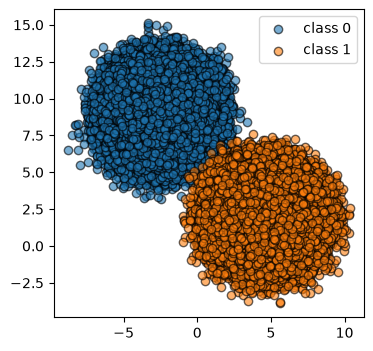

In [9]:
plt.figure(figsize=(4,4))
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], label='class 0', alpha=0.6, edgecolors='k')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], label='class 1', alpha=0.6, edgecolors='k')
_ = plt.legend()

In [10]:
from sklearn.svm import SVC, LinearSVC

model_svc = SVC(kernel='linear') # linear kernel
model_linear_svc = LinearSVC()

fitting

In [11]:
import time

start = time.time()
print('fitting SVC with linear kernel')
model_svc.fit(X_train, y_train)
print(f'-----> {time.time()-start:.5f} s')

start = time.time()
print('fitting Linear SVC')
model_linear_svc.fit(X_train, y_train)
print(f'-----> {time.time()-start:.5f} s')

fitting SVC with linear kernel
-----> 3.63382 s
fitting Linear SVC
-----> 0.32908 s


evaluating

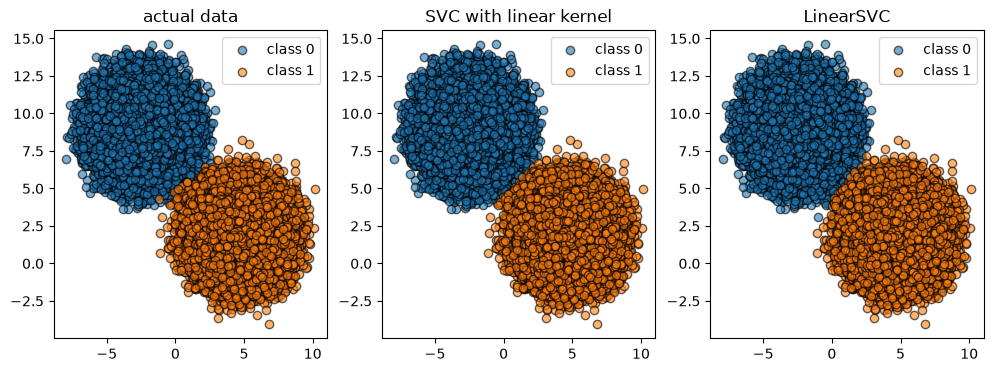

In [12]:
y_pred_svc = model_svc.predict(X_test)
y_pred_linear_svc = model_linear_svc.predict(X_test)

fig, ax = plt.subplots(1, 3, figsize=(12,4))
ax[0].set_title('actual data')
ax[0].scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1], label='class 0', alpha=0.6, edgecolors='k')
ax[0].scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], label='class 1', alpha=0.6, edgecolors='k')

ax[1].set_title('SVC with linear kernel')
ax[1].scatter(X_test[y_pred_svc == 0, 0], X_test[y_pred_svc == 0, 1], label='class 0', alpha=0.6, edgecolors='k')
ax[1].scatter(X_test[y_pred_svc == 1, 0], X_test[y_pred_svc == 1, 1], label='class 1', alpha=0.6, edgecolors='k')

ax[2].set_title('LinearSVC')
ax[2].scatter(X_test[y_pred_linear_svc == 0, 0], X_test[y_pred_linear_svc == 0, 1], label='class 0', alpha=0.6, edgecolors='k')
ax[2].scatter(X_test[y_pred_linear_svc == 1, 0], X_test[y_pred_linear_svc == 1, 1], label='class 1', alpha=0.6, edgecolors='k')
_ = [ax_curr.legend() for ax_curr in ax]

In [13]:
from sklearn.metrics import accuracy_score

print(f'SVC with linear kernel --> {accuracy_score(y_test, y_pred_svc)}')
print(f'LinearSVC --> {accuracy_score(y_test, y_pred_linear_svc)}')

SVC with linear kernel --> 0.9999233333333334
LinearSVC --> 0.9999133333333333


In [15]:
model_linear_svc

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

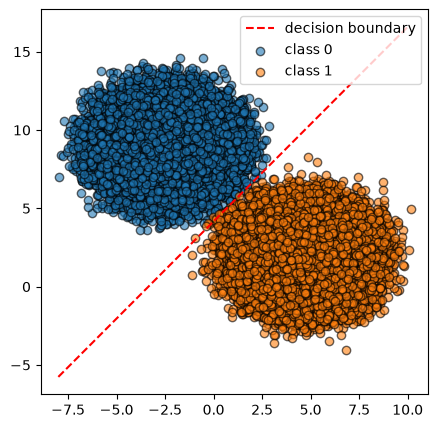

In [28]:
# coef[0]*x + coef[1]*y + intercept = 0
x = np.linspace(-8, 10, 100)
y = (-model_linear_svc.coef_[0,0]*x-model_linear_svc.intercept_)/model_linear_svc.coef_[0,1]
plt.figure(figsize=(5,5))
plt.plot(x, y, '--', c='red', label='decision boundary')
plt.scatter(X_test[y_pred_svc == 0, 0], X_test[y_pred_svc == 0, 1], label='class 0', alpha=0.6, edgecolors='k')
plt.scatter(X_test[y_pred_svc == 1, 0], X_test[y_pred_svc == 1, 1], label='class 1', alpha=0.6, edgecolors='k')
_ = plt.legend()